In [12]:
#EJERCICO:ejecutar DBSCAN sobre digits
#comenzamos por importar las librerias
from IPython.display import Markdown, display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets #agregamos esta linea para definir datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings

In [14]:
#importamos ahora a las imagenes 
digits = datasets.load_digits()
print(digits.DESCR)


.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

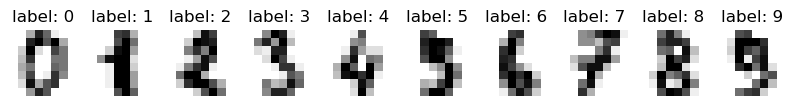

In [16]:
#para ver las imagenes 
_, axes = plt.subplots(nrows=1, ncols=10, figsize=(10, 3))

for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("label: %i" % label)

plt.show()
#plt.matshow(digits.images[0])

In [ ]:
df_digits= sns.load_dataset('digits')


In [18]:
x =digits.data #imagenes aplanadas 
y = digits.target #etiquetas reales 


In [20]:
#para reescalar los datos 
x_scaled = StandardScaler().fit_transform(x)

In [30]:
#se aplica DBSCAN
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
dbscan = DBSCAN(eps=3, min_samples=5)  # se pueden ajustar estos valores
labels = dbscan.fit_predict(x_scaled)

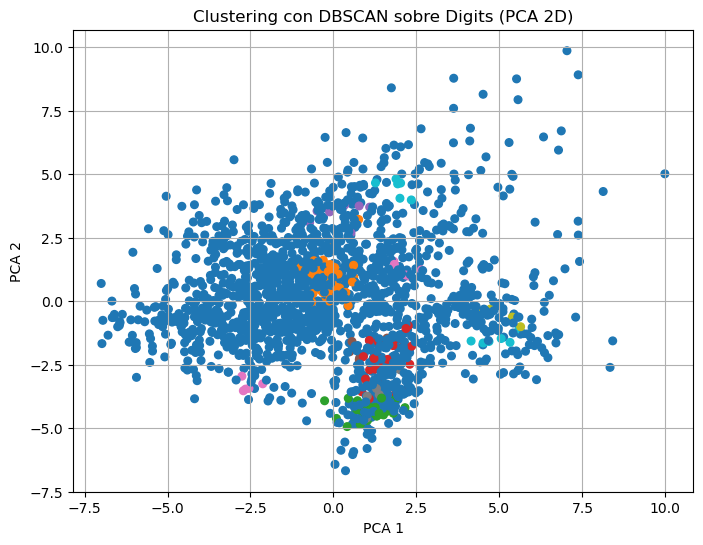

In [32]:
#para mostrar los clouster encontrados 
plt.figure(figsize=(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels, cmap='tab10', s=30)
plt.title("Clustering con DBSCAN sobre Digits (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

In [46]:
#para calcular las medidas de desempeño 
mask = labels != -1
filtered_features = x_scaled[mask]
filtered_labels = labels[mask]
filtered_y = y[mask]

# calcular métricas
sil = silhouette_score(filtered_features, filtered_labels)
ari_score = adjusted_rand_score(filtered_y, filtered_labels)

# mostrar tabla con Markdown
Markdown(f"""
**Resultados de desempeño (sin incluir ruido):**

Particiones: {pd.Series(filtered_labels).value_counts().tolist()}

| Métrica                   | Valor   |
|---------------------------|---------|
| Coeficiente de silueta    | {sil:.3f} |
| Adjusted Rand Index (ARI) | {ari_score:.3f} |
""")


**Resultados de desempeño (sin incluir ruido):**

Particiones: [47, 32, 26, 20, 8, 7, 7, 6, 6, 5, 5, 5, 5]

| Métrica                   | Valor   |
|---------------------------|---------|
| Coeficiente de silueta    | 0.349 |
| Adjusted Rand Index (ARI) | 0.647 |
